# 03. 모델 실험 결과 재현·감사

이 Notebook은 이미 완료된 `20260721_full_fair_v1` Run의 저장 결과를 읽어 비교합니다. **모델을 다시 학습하지 않으며**, 동일 Fold·동일 Feature 조건과 최종 모델 재로딩을 검증합니다.

In [1]:
from pathlib import Path
import json
import joblib
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
comparison = pd.read_csv(ROOT / "artifacts/model_comparison_fair.csv")
fine = pd.read_csv(ROOT / "artifacts/top3_fine_tuning_summary.csv")
scenarios = pd.read_csv(ROOT / "artifacts/threshold_operating_scenarios_v2.csv")
metadata = json.loads((ROOT / "artifacts/model_metadata.json").read_text(encoding="utf-8"))

## 1. 동일 조건 8개 모델 비교

1차 지표는 PR-AUC, 보조 지표는 ROC-AUC·F1·Recall·Precision·FN·FP·Brier입니다.

,model,pr_auc,roc_auc,f1,recall,precision,brier,seconds
0,catboost,0.947622,0.941700,0.847008,0.824181,0.871136,0.095612,15.823208
1,lightgbm,0.947534,0.941629,0.852983,0.867345,0.839089,0.095306,12.198998
2,xgboost,0.947052,0.941105,0.850891,0.845249,0.856608,0.101813,10.060870
3,gradient_boosting,0.946362,0.940415,0.851252,0.852432,0.850075,0.102189,344.859821
4,random_forest,0.939448,0.934125,0.850400,0.853461,0.847361,0.108169,26.168921
5,decision_tree,0.936079,0.933386,0.846347,0.851794,0.840969,0.102677,10.941826
6,logistic,0.906293,0.897232,0.811807,0.809954,0.813669,0.130653,3.748814
7,dummy,0.513386,0.499987,0.678465,1.000000,0.513392,0.249821,2.534538


(0.5, 0.96)

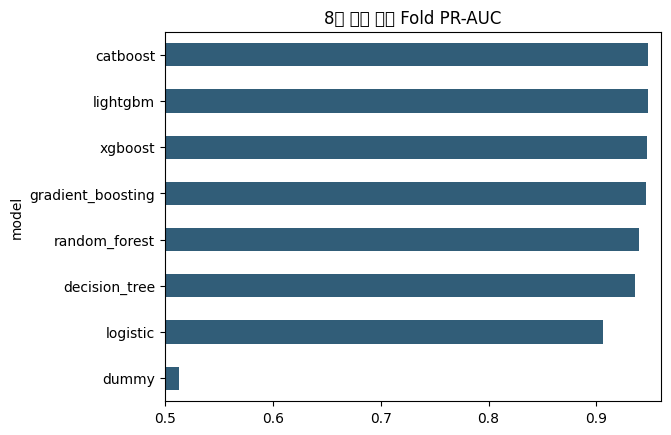

In [2]:
cols = ["model", "pr_auc", "roc_auc", "f1", "recall", "precision", "brier", "seconds"]
display(comparison[cols].sort_values("pr_auc", ascending=False).style.format({c: "{:.6f}" for c in cols[1:7]}))
ax = comparison.sort_values("pr_auc").plot.barh(x="model", y="pr_auc", color="#315d78", legend=False, title="8개 모델 동일 Fold PR-AUC")
ax.set_xlim(0.5, 0.96)

**해석:** Dummy를 제외한 모든 모델이 기준선을 넘었고, CatBoost·LightGBM·XGBoost가 상위권입니다. 기본 Threshold의 F1·Recall이 가장 높다는 이유만으로 모델을 확정하지 않고 순위 품질과 안정성을 추가 검증했습니다.

## 2. 상위 3개 정밀 탐색

In [3]:
display(fine.sort_values("best_cv_pr_auc", ascending=False).style.format({
    "best_cv_pr_auc": "{:.6f}", "pr_auc": "{:.6f}", "roc_auc": "{:.6f}",
    "f1": "{:.6f}", "recall": "{:.6f}", "precision": "{:.6f}", "brier": "{:.6f}",
}))

,model,trials,valid_trials,best_cv_pr_auc,pr_auc,roc_auc,brier,f1,recall,precision,fn,fp,tp,tn
0,catboost,15,15,0.947913,0.947897,0.941959,0.095215,0.849118,0.836382,0.862247,10500,8575,53674,52251
1,lightgbm,15,15,0.947806,0.947790,0.941839,0.095049,0.851892,0.859850,0.844079,8994,10193,55180,50633
2,xgboost,15,15,0.947793,0.947765,0.941818,0.095383,0.850378,0.844283,0.856562,9993,9073,54181,51753


**해석:** CatBoost가 Fine-tuned CV PR-AUC 0.947913으로 근소한 1위입니다. Bootstrap 구간은 겹치므로 절대적 우월성이 아니라, 사전 선정 규칙에서의 기술 후보로 표현합니다.

## 3. Threshold 운영 시나리오

Threshold는 모델 선택과 분리된 운영 결정입니다.

In [4]:
cat = scenarios.query("model == 'catboost'")[["scenario", "threshold", "f1", "recall", "precision", "fn", "fp"]]
display(cat.style.format({"threshold": "{:.2f}", "f1": "{:.4f}", "recall": "{:.4f}", "precision": "{:.4f}", "fn": "{:,.0f}", "fp": "{:,.0f}"}))

,scenario,threshold,f1,recall,precision,fn,fp
0,recall_first,0.29,0.8611,0.9518,0.7861,"3,091","16,617"
1,balanced_f1,0.35,0.8638,0.9444,0.7959,"3,569","15,538"
2,precision_first,0.74,0.8181,0.7180,0.9507,"18,099","2,388"


**해석:** 균형형 0.35는 Recall 0.9444와 Precision 0.7959를 제공하지만, 재현율 우선과 정밀도 우선은 접촉 규모·FN·FP를 크게 바꿉니다. 실제 운영안은 사업 담당자가 선택해야 합니다.

## 4. 저장 모델 새 입력 예측

In [5]:
model = joblib.load(ROOT / "models/churn_pipeline.joblib")
sample = pd.read_csv(ROOT / "data/test.csv").head(1)
probability = float(model.predict_proba(sample)[0, 1])
print({"customer_id": int(sample.iloc[0].customer_id), "churn_probability": probability, "threshold": 0.35})

{'customer_id': 200000, 'churn_probability': 0.8868265551077926, 'threshold': 0.35}


**검증 결론:** 저장 Pipeline이 새 프로세스에서 로드되고 원본 스키마의 신규 고객을 예측합니다. 제공 Test에는 정답 라벨이 없으므로 이 확률은 추론 결과이며 성능 평가가 아닙니다.

## 5. 최종 선정과 한계

- 최종 기술 후보: **CatBoost**
- 선정 근거: Fine-tuned CV PR-AUC, OOF PR-AUC, 5개 Seed 평균, Bootstrap 안정성
- 기본 화면 시나리오: Threshold 0.35(균형형 F1), 사업 확정값 아님
- 한계: 외부 라벨 Holdout·예측 기간·실제 캠페인 Uplift·ROI 미검증